<a href="https://colab.research.google.com/github/retired-snail0345/cap-comp215/blob/main/Project_2_Traffic_Simulation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# COMP 215 Project 2 - Traffic Simulation with Rule 184

Extending Lab 5 to simulate 1D traffic flow. Starts with Rule 184, then builds out two more realistic rules (4-bit and 5-bit lookahead), and finishes with a quick algorithm analysis.

Author: Lakshay / Luckshay

Date: April 2026

In [1]:
%matplotlib inline
import matplotlib.pyplot as plt
import numpy as np
import timeit
from matplotlib.animation import FuncAnimation
from matplotlib import rc

## Upgrading Cell1D

From Lab 5, ffor animating a CA I'm adding a `generate` method that just yields the next state and keeps memory low.

In [3]:
def get_lookup_table(rule, bits=8):
    """return the transition table for a rul,(8 for 3-cell neighbourhood, 16 for 4-cell, 32 for 5-cell)"""
    #s tore rule as uint64, then unpack the bytes.
    rule_arr = np.array([rule], dtype=np.uint64).view(np.uint8)
    unpacked = np.unpackbits(rule_arr, bitorder='little')
    return unpacked[:bits]

In [4]:
#test
assert np.all(get_lookup_table(184) == [0,0,0,1,1,1,0,1])
assert len(get_lookup_table(58336, bits=16)) == 16
assert len(get_lookup_table(100000, bits=32)) == 32

In [5]:
#3-, 4-, and 5-cell neighbourhoods has entries for POWER OF 2
POWERS_OF_2 = {
    3: np.array([4, 2, 1]),
    4: np.array([8, 4, 2, 1]),
    5: np.array([16, 8, 4, 2, 1]),
}

def rule_indexes(state, n=3, wrap=True):
    '''
    sliding dot product to get rule index for each neighbourhood.
    For traffic rules the 'self' cell sits at position 1 in the window,
    so padding is 1 on the left and n-2 on the right.
    '''
    powers = POWERS_OF_2[n]
    mode = 'wrap' if wrap else 'constant'
    padded = np.pad(state, (1, n-2), mode=mode)
    return np.correlate(padded, powers, mode='valid')

In [6]:
def plot_ca(array, axes=None, title='', cmap='Blues'):
    axes = axes or plt.gca()
    axes.set(title=title, ylabel='Time')
    axes.tick_params(axis='x', which='both', bottom=False, labelbottom=False)
    axes.imshow(array, cmap=cmap, interpolation='nearest', origin='upper')


class Cell1D:
    def __init__(self, rule, m=100, bits=8, wrap=True):
        self.m = m
        self.bits = bits
        self.wrap = wrap
        self.n = int(np.log2(bits))   #neighbourhood size- 8to 3, 16 to 4, 32 to 5
        self.rule = get_lookup_table(rule, bits=bits)
        self.state = np.zeros(m, dtype=np.uint8)
        self.ca = np.array([self.state], dtype=np.uint8)

    def start_random(self, p=0.5, seed=None):
        rng = np.random.default_rng(seed)
        self.state = (rng.random(self.m) < p).astype(np.uint8)
        self.ca = np.array([self.state], dtype=np.uint8)

    def start_string(self, s):
        self.state = np.array([int(c) for c in s], dtype=np.uint8)
        self.m = len(self.state)
        self.ca = np.array([self.state], dtype=np.uint8)

    def step(self):
        idx = rule_indexes(self.state, self.n, self.wrap)
        self.state = self.rule[idx]
        self.ca = np.vstack([self.ca, self.state])

    def simulate(self, n_steps):
        for _ in range(n_steps):
            self.step()

    def generate(self, n_steps=None):
        '''
        Generator: yields next state without building up the 2D grid.
        Much lighter on memory than simulate() when you just want to animate
        or measure something as you go
        '''
        count = 0
        while n_steps is None or count < n_steps:
            idx = rule_indexes(self.state, self.n, self.wrap)
            self.state = self.rule[idx]
            count += 1
            yield self.state

    def draw(self, **kwargs):
        plot_ca(self.ca, **kwargs)

### Tests for the upgraded class

Making sure `generate` actually works the same as `step`

In [10]:
#Test 1: rule 184 moves cars to the right
ca = Cell1D(184, m=6)
ca.start_string('101010')
ca.step()
assert np.all(ca.state == [0,1,0,1,0,1]), f'got {ca.state}'
print('done')

done


In [11]:
#Test 2: wrapping works as car at right edge should appear on the left next step
ca = Cell1D(184, m=6)
ca.start_string('000001')
ca.step()
assert np.all(ca.state == [1,0,0,0,0,0])
print('done')

done


In [12]:
#Test3: generate produces same sequence as step()
a = Cell1D(184, m=20); a.start_random(p=0.4, seed=42)
b = Cell1D(184, m=20); b.start_random(p=0.4, seed=42)
gen = b.generate()
for _ in range(10):
    a.step()
    assert np.all(a.state == next(gen))
print('done')

done


In [13]:
#Test 4: generatedoesn't grow the 2D grid
ca = Cell1D(184, m=50)
ca.start_random(p=0.3, seed=0)
gen = ca.generate()
for _ in range(100):
    next(gen)
assert ca.ca.shape == (1, 50)
print('done')

done


## Rule 184 Animation

Using the animation code from the project sheet.

In [15]:
from matplotlib.animation import FuncAnimation
from matplotlib import rc
class CAanimation:
    """ Animates a 1D cellular automata """
    def __init__(self, ca, frames=25, figsize=(20, 8), cmap='Blues'):
        self.ca = ca
        self.cmap = cmap
        fig, self.ax = plt.subplots(figsize=figsize)
        self.animation = FuncAnimation(fig, self.animate, frames=range(frames))

    def animate(self, step):
        """ Generate image of current state and move the animation forward one step """
        im = self.ax.imshow(ca.state.reshape(1, self.ca.m),
                            cmap=self.cmap, interpolation=None, animated=True)
        self.ca.step()
        return [im,]

    def show(self):
        """ return the matplotlib animation, ready for display """ # turn off axis tick
        #marks
        plt.xticks([])
        plt.yticks([])
        plt.close()
        rc('animation', html='jshtml')
        return self.animation

# run animation
n_frames = 25
ca = Cell1D(184, m=100)
ca.start_random(p=0.5)
animation = CAanimation(ca, frames=n_frames)
animation.show()

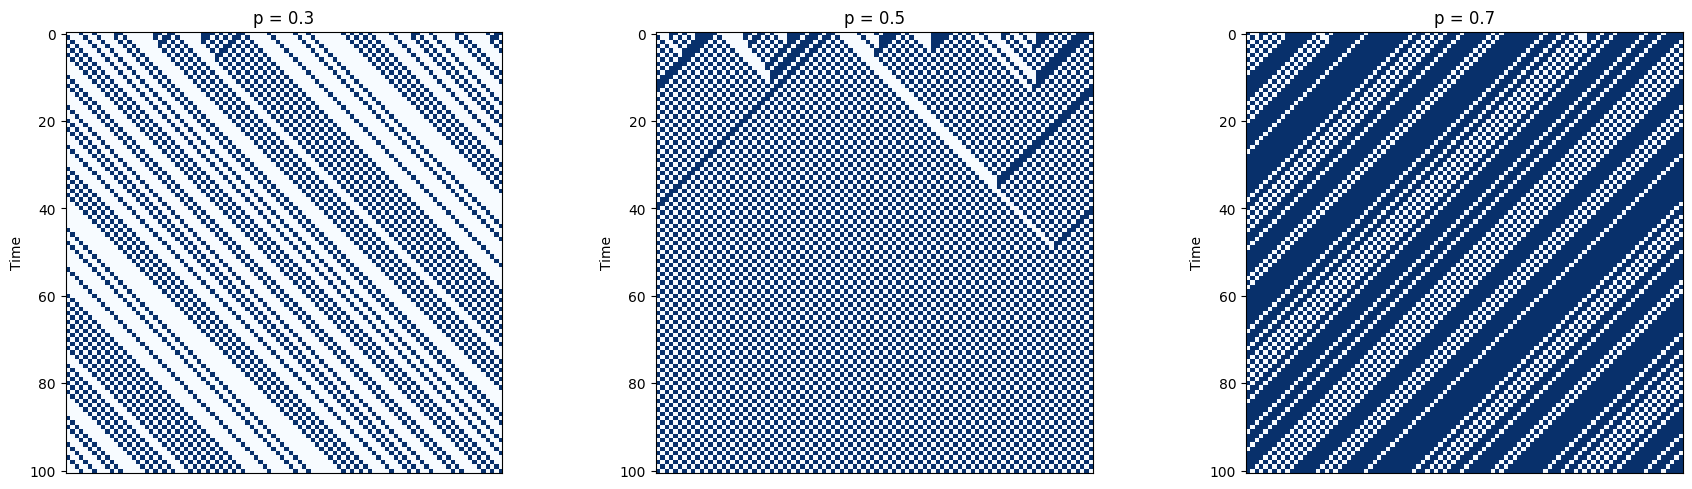

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, p in zip(axes, [0.3, 0.5, 0.7]):
    ca = Cell1D(184, m=100)
    ca.start_random(p=p, seed=7)
    ca.simulate(100)
    plot_ca(ca.ca, axes=ax, title=f'p = {p}')
plt.tight_layout()
plt.show()

### Detecting jams

Counting cars that don't move on the next step. A bit more work but more meaningful.

In [21]:
def count_stuck_cars(ca):
    '''
    Number of cars whose next-step position is still occupied (i.e. they don't move).
    '''
    idx = rule_indexes(ca.state, ca.n, ca.wrap)
    next_state = ca.rule[idx]
    return int((ca.state & next_state).sum())


def jam_experiment(rule, bits, p_values, m=200, trials=5, seed=0):
    '''
    For each p in p_values, run several trials and return mean stuck-car count.
    Lets the CA relax for m steps first, then averages over another m steps.
    '''
    results = np.zeros(len(p_values))
    rng = np.random.default_rng(seed)
    for i, p in enumerate(p_values):
        trial_means = []
        for _ in range(trials):
            ca = Cell1D(rule, m=m, bits=bits)
            ca.start_random(p=p, seed=int(rng.integers(0, 2**31)))
            gen = ca.generate()

            for _ in range(m):
                next(gen)
            # measurements
            stuck = []
            for _ in range(m):
                stuck.append(count_stuck_cars(ca))
                next(gen)
            trial_means.append(np.mean(stuck))
        results[i] = np.mean(trial_means)
    return results

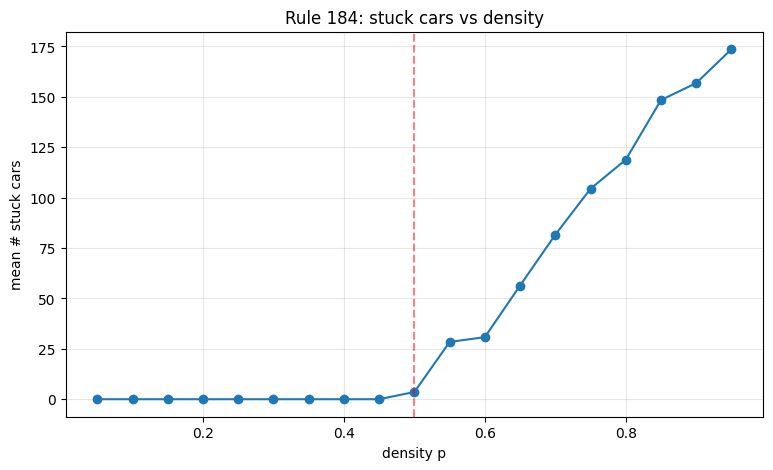

In [22]:
p_values = np.linspace(0.05, 0.95, 19)
jams_184 = jam_experiment(184, bits=8, p_values=p_values, m=200, trials=5)

plt.figure(figsize=(9, 5))
plt.plot(p_values, jams_184, 'o-')
plt.axvline(0.5, color='red', linestyle='--', alpha=0.5)
plt.xlabel('density p')
plt.ylabel('mean # stuck cars')
plt.title('Rule 184: stuck cars vs density')
plt.grid(alpha=0.3)
plt.show()

## Extending Model Further

Extend the rule to look 2 cells ahead, and only move if both of them are empty.

Neighbourhood now has 4 cells: `[arriving, self, la1, la2]`. The cell we're updating is at position 1.

Logic:
- If self = 1 (there's a car here): move forward if la1 AND la2 are both 0, otherwise stay put.
- If self = 0 (empty): a car arrives if arriving = 1 AND la1 = 0 (because the arriving car needs 2 empty cells ahead of it, which are self=0 and la1).

Working through the 16 states:

| state | new self | | state | new self |
|---|---|---|---|---|
| 1111 | 1 | | 0111 | 1 |
| 1110 | 1 | | 0110 | 1 |
| 1101 | 1 | | 0101 | 1 |
| 1100 | 0 | | 0100 | 0 |
| 1011 | 0 | | 0011 | 0 |
| 1010 | 0 | | 0010 | 0 |
| 1001 | 1 | | 0001 | 0 |
| 1000 | 1 | | 0000 | 0 |

output from 1111 down to 0000 gives: `1110 0011 1110 0000`.

So,
- 1100 → 0: car here, two empty cells ahead, it moves out
- 1001 → 1: empty here, car behind wants to move in, and its lookahead

In [23]:
def binary_to_decimal(bits):
    '''
    Convert MSB-first array of 0s and 1s to an integer.
    '''
    val = 0
    for b in bits:
        val = (val << 1) | int(b)
    return val

assert binary_to_decimal([1,1,0,1]) == 13
assert binary_to_decimal([1,0,0,0,0,0,0,0]) == 128

# rule bits,(state 1111 down to 0000)
rule4_bits = [1,1,1,0, 0,0,1,1, 1,1,1,0, 0,0,0,0]
rule4 = binary_to_decimal(rule4_bits)
print('4-bit rule number:', rule4)

4-bit rule number: 58336


##5 bit rule

5-cell neighbourhood: `[arriving, self, la1, la2, la3]`, 32 possible states. This one took me a while to work through, I had to draw it out on paper a few times.

| state | new s | | state | new s | | state | new s | | state | new s |
|---|---|---|---|---|---|---|---|---|---|---|
| 11111 | 1 | | 10111 | 1 | | 01111 | 1 | | 00111 | 0 |
| 11110 | 1 | | 10110 | 1 | | 01110 | 1 | | 00110 | 0 |
| 11101 | 1 | | 10101 | 0 | | 01101 | 1 | | 00101 | 0 |
| 11100 | 1 | | 10100 | 0 | | 01100 | 1 | | 00100 | 0 |
| 11011 | 0 | | 10011 | 1 | | 01011 | 0 | | 00011 | 0 |
| 11010 | 1 | | 10010 | 1 | | 01010 | 1 | | 00010 | 0 |
| 11001 | 0 | | 10001 | 1 | | 01001 | 0 | | 00001 | 0 |
| 11000 | 0 | | 10000 | 1 | | 01000 | 0 | | 00000 | 0 |

`11011 → 0` and `01011 → 0`

In [28]:
# New s ,  11111 down to 00000
rule5_bits = [1,1,1,1, 0,1,0,0,   # 11111-11000
              1,1,0,0, 1,1,1,1,   # 10111-10000
              1,1,1,1, 0,1,0,0,   # 01111-01000
              0,0,0,0, 0,0,0,0]   # 00111-00000
rule5 = binary_to_decimal(rule5_bits)
print('5-bit rule number:', rule5)

5-bit rule number: 4107269120


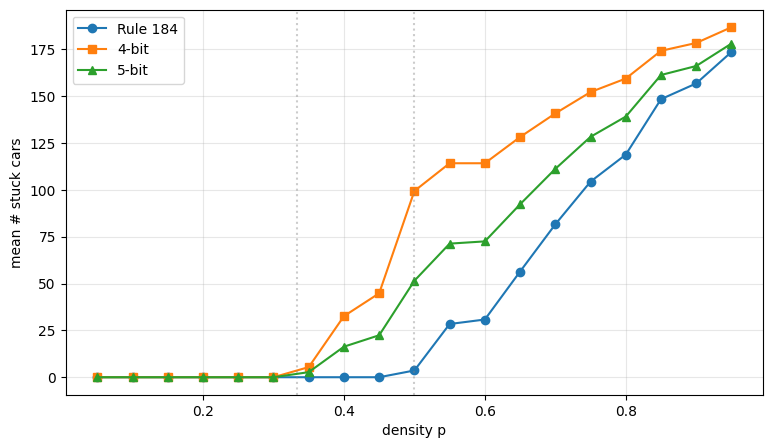

In [30]:
jams_4bit = jam_experiment(rule4, bits=16, p_values=p_values, m=200, trials=5)
jams_5bit = jam_experiment(rule5, bits=32, p_values=p_values, m=200, trials=5)

plt.figure(figsize=(9, 5))
plt.plot(p_values, jams_184, 'o-', label='Rule 184')
plt.plot(p_values, jams_4bit, 's-', label='4-bit')
plt.plot(p_values, jams_5bit, '^-', label='5-bit')
plt.axvline(1/3, color='gray', linestyle=':', alpha=0.4)
plt.axvline(0.5, color='gray', linestyle=':', alpha=0.4)
plt.xlabel('density p')
plt.ylabel('mean # stuck cars')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

## Algorithm Analysis


In [25]:
def time_it(m, n_steps=500):
    ca = Cell1D(184, m=m)
    ca.start_random(p=0.5, seed=0)
    gen = ca.generate()
    start = timeit.default_timer()
    for _ in range(n_steps):
        next(gen)
    return timeit.default_timer() - start

# scaling with m
ms = [1000, 3000, 10000, 30000, 100000, 300000]
t_ms = [time_it(m, n_steps=200) for m in ms]

# scaling with n
ns = [100, 300, 1000, 3000, 10000]
t_ns = [time_it(m=5000, n_steps=n) for n in ns]

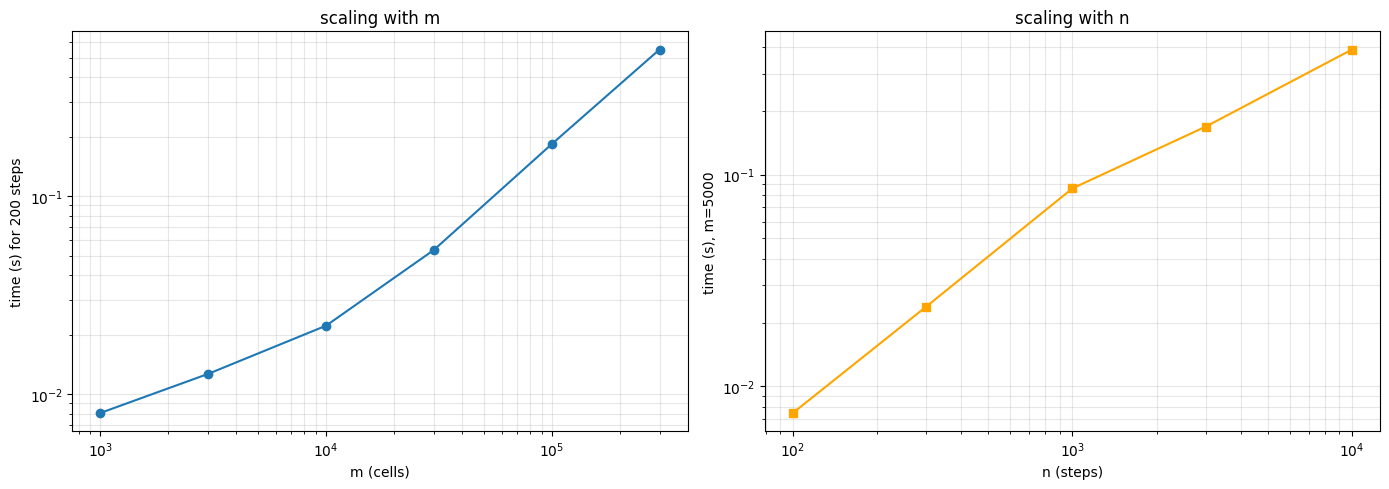

slope vs m: 0.75  (expected ~1.0)
slope vs n: 0.86  (expected ~1.0)


In [26]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

ax[0].loglog(ms, t_ms, 'o-')
ax[0].set_xlabel('m (cells)')
ax[0].set_ylabel('time (s) for 200 steps')
ax[0].set_title('scaling with m')
ax[0].grid(which='both', alpha=0.3)

ax[1].loglog(ns, t_ns, 's-', color='orange')
ax[1].set_xlabel('n (steps)')
ax[1].set_ylabel('time (s), m=5000')
ax[1].set_title('scaling with n')
ax[1].grid(which='both', alpha=0.3)

plt.tight_layout()
plt.show()

# fit slopes to check
slope_m = np.polyfit(np.log(ms), np.log(t_ms), 1)[0]
slope_n = np.polyfit(np.log(ns), np.log(t_ns), 1)[0]
print(f'slope vs m: {slope_m:.2f}  (expected ~1.0)')
print(f'slope vs n: {slope_n:.2f}  (expected ~1.0)')